In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

In [23]:
df = pd.read_csv("sales.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


In [24]:
train = df.iloc[:-14]
test = df.iloc[-14:]
h = len(test)

# Step 1 - Determine d (differencing order)

In [25]:
def stationarity_test(series, name):
    # runs ADF test. .dropna() removes NaN values created by differencing. autolag='AIC' selects optimal lag count automatically
    result = adfuller(series.dropna(), autolag="AIC")
    # extracts the p-value from the ADF result tuple.
    p_val = result[1]
    print(f"{name}: ADF p-value = {p_val:.4f}")
    # returns a boolean. True means stationary
    if p_val < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")
    return p_val < 0.05

In [26]:
is_stat = stationarity_test(train["sales"], "Raw Series")

Raw Series: ADF p-value = 0.9935
Non-stationary


In [27]:
# if the raw series is not stationary, apply first differencing.
if not is_stat:
    #  differences the series once and drops the leading NaN.
    sales_diff1 = train["sales"].diff().dropna()
    is_stat_d1 = stationarity_test(sales_diff1, "After diff(1)")
    # records that one differencing was needed. This becomes the d in ARIMA(p, d, q)
    d = 1
else:
    # if the series was already stationary, no differencing needed
    d = 0

print(f"Differencing order d = {d}")

After diff(1): ADF p-value = 0.0000
Stationary
Differencing order d = 1


# Step 2: Identify p and q from ACF and PACF

In [28]:
# selects the correct series for plotting. If d=1 was needed, plot the differenced version. If d=0, plot the original. ACF and PACF must be run on the stationary series — the same series that will feed into the AR and MA components.

if d == 1:
    stationary_series = train["sales"].diff().dropna()
else:
    stationary_series = train["sales"]

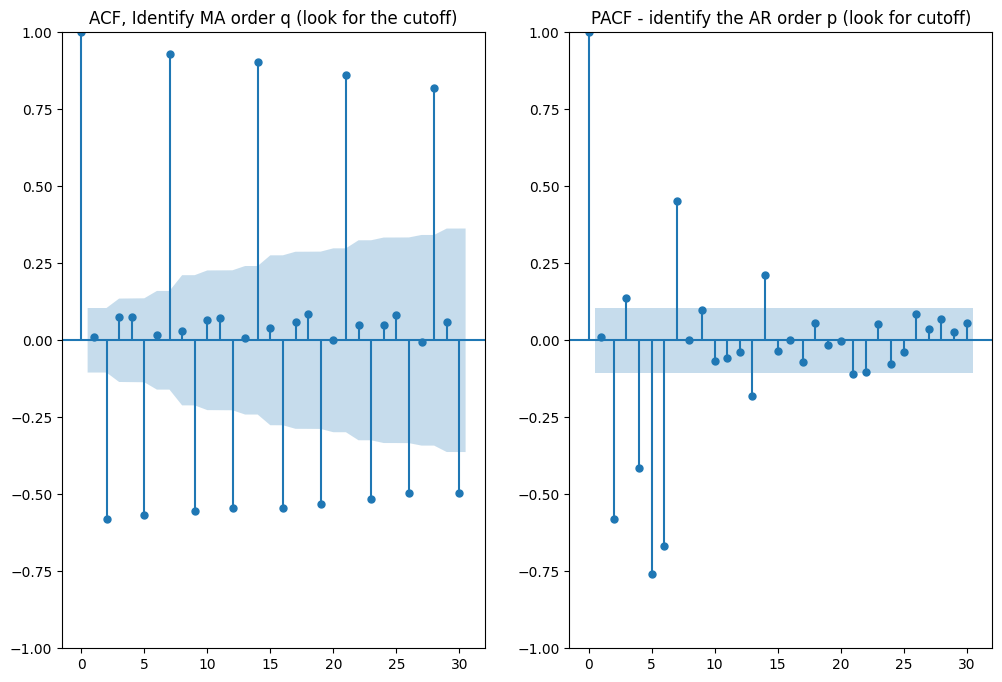

In [29]:
fig, axes = plt.subplots(1, 2, figsize = (12, 8))

plot_acf(stationary_series, lags=30, ax=axes[0], title="ACF, Identify MA order q (look for the cutoff)")
plot_pacf(stationary_series, lags=30, method = "ywm", ax=axes[1], title="PACF - identify the AR order p (look for cutoff)")

plt.tight_layout
plt.show()

# Step 3: Fit ARIMA

In [32]:
p, d, q = 7, 1, 0

# train['sales'] — the original undifferenced series. Unlike AutoReg where you pass the differenced series manually, ARIMA handles differencing internally based on the d parameter. You always pass the original series.
model  = ARIMA(train['sales'], order=(p, d, q))

# estimates all coefficients using Maximum Likelihood Estimation (MLE). Unlike the simpler OLS used by AutoReg, MLE is more appropriate for ARIMA because it properly handles the MA component and the differencing. Returns a fitted model object.
fitted = model.fit()

# prints the complete model output including all coefficients, standard errors, p-values, AIC, BIC, and log-likelihood.
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  351
Model:                 ARIMA(7, 1, 0)   Log Likelihood               -2142.163
Date:                Fri, 19 Jun 2026   AIC                           4300.326
Time:                        03:07:27   BIC                           4331.189
Sample:                    01-01-2022   HQIC                          4312.611
                         - 12-17-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5879      0.020    -29.376      0.000      -0.627      -0.549
ar.L2         -0.6906      0.029    -24.064      0.000      -0.747      -0.634
ar.L3         -0.6231      0.026    -24.166      0.0

# Step 4: Try multiple Specifications and compare

In [33]:
specifications = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (7, 1, 0),
    (7, 1, 1),
    (2, 1, 2),
]

results = []
for spec in specifications:
    try:
        m = ARIMA(train['sales'], order=spec).fit()
        results.append({
            'order'  : spec,
            'AIC'    : round(m.aic, 2),
            'BIC'    : round(m.bic, 2),
            'params' : len(m.params)
        })
    except:
        pass

results_df = pd.DataFrame(results).sort_values('AIC')
print(results_df.to_string(index=False))

    order     AIC     BIC  params
(7, 1, 0) 4300.33 4331.19       8
(7, 1, 1) 4311.29 4346.01       9
(2, 1, 2) 4978.34 4997.63       5
(1, 1, 1) 5178.83 5190.40       3
(0, 1, 1) 5226.91 5234.63       2
(1, 1, 0) 5246.54 5254.26       2


# Step 5: Forecast

In [34]:
best_order = results_df.iloc[0]['order']
print(f"Best order by AIC: ARIMA{best_order}")

final_model  = ARIMA(train['sales'], order=best_order)
final_fitted = final_model.fit()

forecast_result = final_fitted.get_forecast(steps=h)
fc_mean         = forecast_result.predicted_mean
fc_ci           = forecast_result.conf_int(alpha=0.05)

Best order by AIC: ARIMA(7, 1, 0)


# Step 6: Check residuals (Most critical Step)

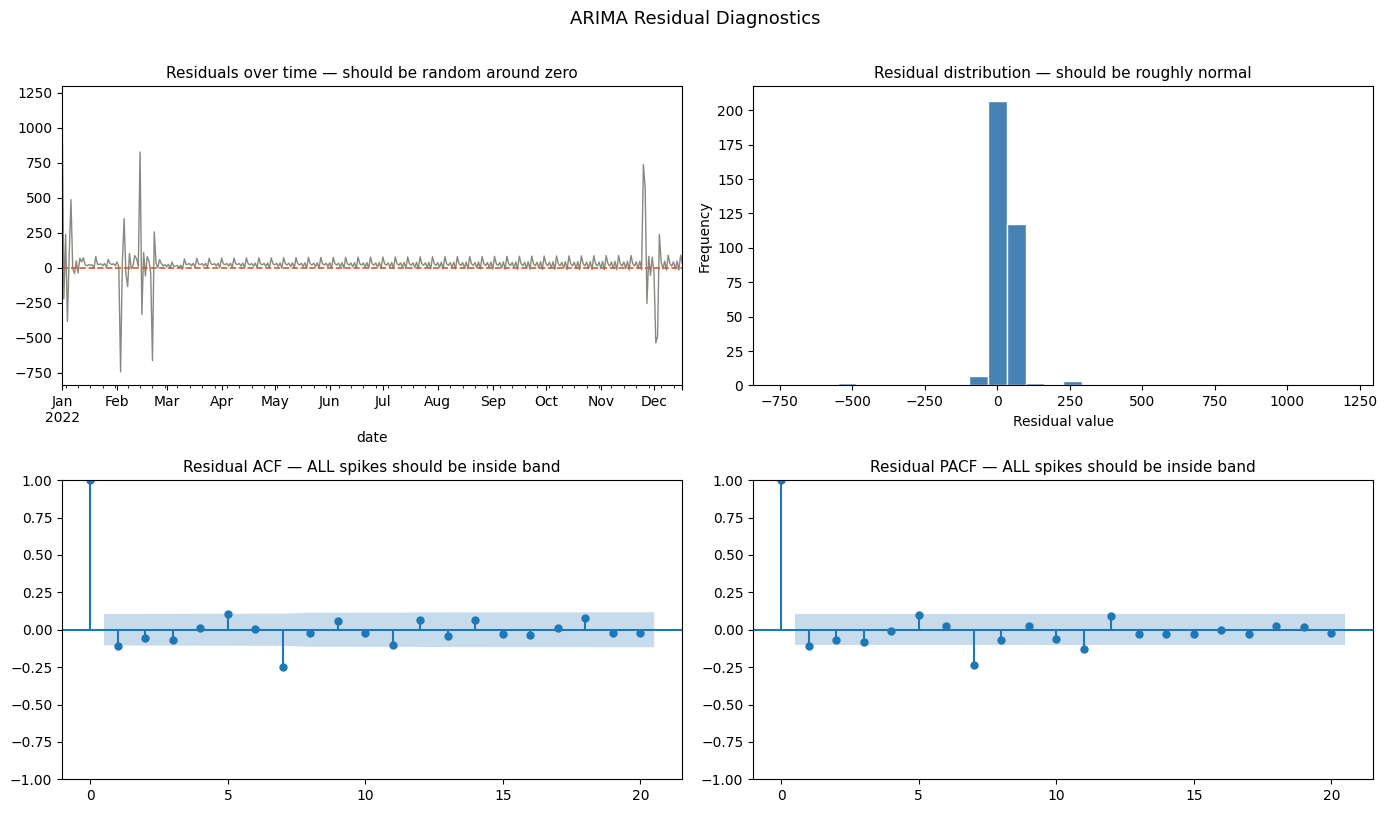

In [35]:
residuals = final_fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1 — residuals over time
residuals.plot(ax=axes[0,0], color='#888780', linewidth=1.0)
axes[0,0].axhline(0, color='#D85A30', linewidth=1.2, linestyle='--')
axes[0,0].set_title('Residuals over time — should be random around zero',
                     fontsize=11)

# Panel 2 — residual distribution
residuals.plot(kind='hist', ax=axes[0,1], bins=30,
               color='steelblue', edgecolor='white')
axes[0,1].set_title('Residual distribution — should be roughly normal',
                     fontsize=11)
axes[0,1].set_xlabel('Residual value')

# Panel 3 — residual ACF
plot_acf(residuals.dropna(), lags=20, ax=axes[1,0])
axes[1,0].set_title('Residual ACF — ALL spikes should be inside band',
                     fontsize=11)

# Panel 4 — residual PACF
plot_pacf(residuals.dropna(), lags=20, method='ywm', ax=axes[1,1])
axes[1,1].set_title('Residual PACF — ALL spikes should be inside band',
                     fontsize=11)

plt.suptitle('ARIMA Residual Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('arima_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 7 — Ljung-Box Test (Formal Residual Test)

In [36]:
lb_test = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
print("\nLjung-Box test on residuals:")
print(lb_test)
print("\nAll p-values > 0.05 means residuals are white noise ✓")


Ljung-Box test on residuals:
      lb_stat  lb_pvalue
10  34.657318   0.000143
20  45.968751   0.000814

All p-values > 0.05 means residuals are white noise ✓


# Step 8 — The Final Plot

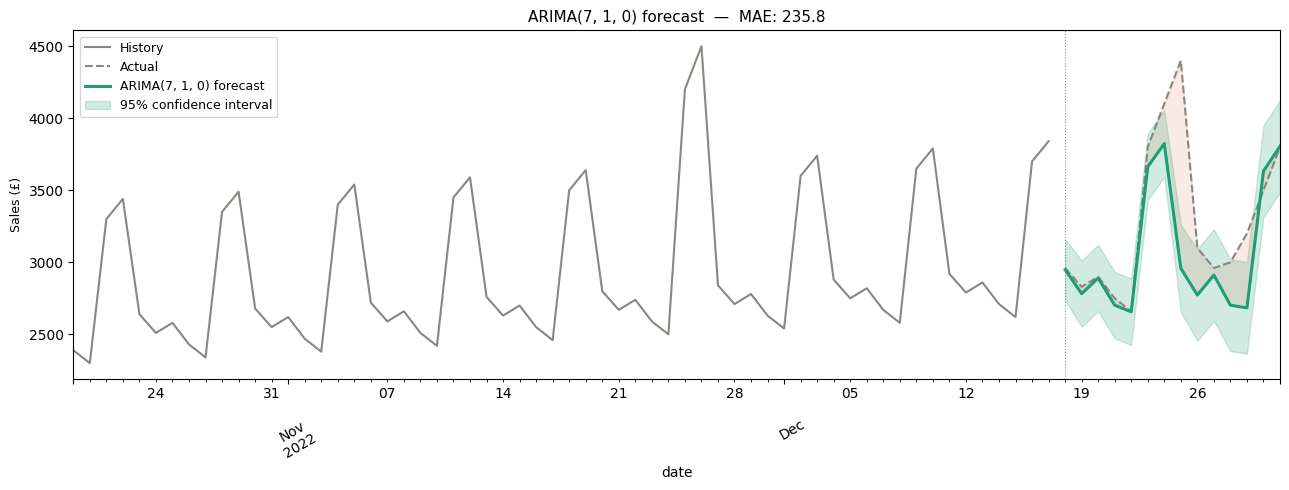

In [37]:
fig, ax = plt.subplots(figsize=(13, 5))

# Last 60 days of training — context
train['sales'].iloc[-60:].plot(ax=ax, color='#888780',
                                linewidth=1.5, label='History')

# Actual test values — ground truth
test['sales'].plot(ax=ax, color='#888780', linewidth=1.5,
                   linestyle='--', label='Actual')

# Point forecast
fc_mean.plot(ax=ax, color='#1D9E75', linewidth=2.2,
             label=f'ARIMA{best_order} forecast')

# Confidence interval — shaded band around forecast
ax.fill_between(fc_ci.index,
                fc_ci.iloc[:, 0],
                fc_ci.iloc[:, 1],
                alpha=0.20, color='#1D9E75',
                label='95% confidence interval')

# Error region between forecast and actual
ax.fill_between(test.index,
                fc_mean.values,
                test['sales'].values,
                alpha=0.12, color='#D85A30')

# Forecast start marker
ax.axvline(test.index[0], color='#888780', linewidth=0.8, linestyle=':')

mae_val = np.mean(np.abs(fc_mean - test['sales']))
ax.set_title(f'ARIMA{best_order} forecast  —  MAE: {mae_val:.1f}', fontsize=11)
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Sales (£)', fontsize=9)

plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()